Matrix #   Size       Naive Time (s)     NumPy Time (s)    
------------------------------------------------------------
1          3x3        0.000042           0.000027          
2          6x6        0.000209           0.000014          
3          12x12      0.001548           0.000014          
4          24x24      0.012670           0.000067          
5          48x48      0.099588           0.000070          
6          96x96      0.755931           0.000330          
7          192x192    6.077872           0.000649          
8          384x384    47.323940          0.003346          


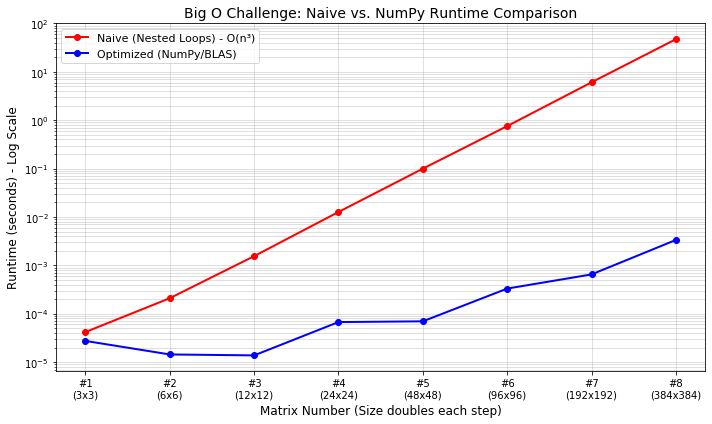

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt


def naive_multiply(A, B):
   
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    
    # Result matrix initialized with zeros
    C = np.zeros((rows_A, cols_B))
    
    for i in range(rows_A):          # Loop over rows of A
        for j in range(cols_B):      # Loop over columns of B
            for k in range(cols_A):  # Dot product summation loop
                C[i, j] += A[i, k] * B[k, j]
    return C

# Matrix growth: 3x3, 6x6, 12x12, 24x24, 48x48, 96x96, 192x192, 384x384
matrix_numbers = np.arange(1, 9)
sizes = [3 * (2**(i-1)) for i in matrix_numbers]

naive_times = []
numpy_times = []

print(f"{'Matrix #':<10} {'Size':<10} {'Naive Time (s)':<18} {'NumPy Time (s)':<18}")
print("-" * 60)

# Execution Loop
for i, n in enumerate(sizes):
    # Build a pair of random matrices (16 total over the 8 iterations)
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    
    # Time the Naive implementation
    start_naive = time.perf_counter()
    _ = naive_multiply(A, B)
    end_naive = time.perf_counter()
    t_naive = end_naive - start_naive
    naive_times.append(t_naive)
    
    # Time the NumPy implementation
    start_numpy = time.perf_counter()
    _ = np.dot(A, B)
    end_numpy = time.perf_counter()
    t_numpy = end_numpy - start_numpy
    numpy_times.append(t_numpy)
    
    
    print(f"{i+1:<10} {f'{n}x{n}':<10} {t_naive:<18.6f} {t_numpy:<18.6f}")

# visualization
plt.figure(figsize=(10, 6))

# Plotting on a log scale
plt.plot(matrix_numbers, naive_times, 'ro-', linewidth=2, label='Naive (Nested Loops) - O(n³)')
plt.plot(matrix_numbers, numpy_times, 'bo-', linewidth=2, label='Optimized (NumPy/BLAS)')

plt.title('Big O Challenge: Naive vs. NumPy Runtime Comparison', fontsize=14)
plt.xlabel('Matrix Number (Size doubles each step)', fontsize=12)
plt.ylabel('Runtime (seconds) - Log Scale', fontsize=12)

# x-axis labels to show actual matrix dimensions
plt.xticks(matrix_numbers, [f"#{i}\n({s}x{s})" for i, s in zip(matrix_numbers, sizes)])

plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig('matrix_comparison_plot.png')
plt.show()